In [ ]:
from transformers import DataCollatorWithPadding
import torch
import torch.nn as nn
from transformers import Trainer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
from datasets import load_dataset
import os
from transformers import AutoTokenizer, EarlyStoppingCallback
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments
from transformers import Trainer
from transformers import AutoConfig
from evaluate import load
import matplotlib.pyplot as plt
from torch import nn
import pandas as pd
from datasets import DatasetDict, Dataset
import time 
from safetensors.torch import load_file  # comes with HF if safetensors installed
os.chdir("/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis")
from sklearn.metrics import f1_score

In [ ]:

tik = time.time()

#### Run Params

train_full_model = True
all_labels = False
model_name = "ProsusAI/finbert"
model_name = "bert-base-uncased"
num_layers = 2

#####

mypath = "/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/"

#data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/test_read_training_data_right_classifications/paragraph_and_sentence_len_5_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx_with_null/"
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/test_read_training_data/paragraph_and_sentence_len_5_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx_with_no_class/"
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/training_data/paragraph_and_sentence_len_4_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx/"
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/test_read_training_data/paragraph_and_sentence_len_5_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx_with_no_class__cos_sim_04/"
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks_labeling"
data_path = "../../data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks_labeling"
data_path = mypath + "data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks_labeling"
data_path = mypath + "data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks__with_null_classifiers__nace_level_1"
data_path = mypath + "data/training_data/dataset_reports_subset_from_full_data_1__sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__2nd_approach__nace_level_1__cos_thres_0.35"

new_thresh = 0.35

results_path = mypath + f"results/BERT_models/results__new_approach_data__num_layers_{num_layers}__cos_thres_{new_thresh}" + os.path.basename(model_name)
#results_path = mypath + f"results/BERT_models/___results_null_classifiers__cos_thres_{new_thresh}__num_layers_{num_layers}" + os.path.basename(model_name)
if train_full_model: 
    results_path += "__train_full_model" 
else: 
    results_path += "__train_classifier_only" 

if all_labels: 
    results_path += "__all_labels" 
else: 
    results_path += "__some_labels" 
    
os.makedirs(results_path, exist_ok = True)

print(results_path)

/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/results/BERT_models/results__new_approach_data__num_layers_2__cos_thres_0.35bert-base-uncased__train_full_model__some_labels


In [3]:

# Load a custom CSV file
data_files = {"train": os.path.join(data_path, "train_data.csv"), "test": os.path.join(data_path, "test_data.csv"), "validation": os.path.join(data_path, "val_data.csv")}
# Load the CSV files using pandas
train_df = pd.read_csv(data_files["train"])
test_df = pd.read_csv(data_files["test"])
validation_df = pd.read_csv(data_files["validation"])

train_df = train_df[(train_df["Score"] > new_thresh) | (train_df["NACE_Code"] == "NO_CLASS")]
validation_df = validation_df[(validation_df["Score"] > new_thresh) | (test_df["NACE_Code"] == "NO_CLASS")]
test_df = test_df[(test_df["Score"] > new_thresh) | (test_df["NACE_Code"] == "NO_CLASS")]


if not all_labels: 
    #train_df = train_df[train_df["NACE_Code"]!="C"]
    #train_df = train_df[train_df["NACE_Code"]!="P"]
    #train_df = train_df[train_df["NACE_Code"]!="M"]
    #train_df = train_df[train_df["NACE_Code"]!="M"]
    train_df = train_df[train_df["NACE_Code"]!="R"]
    train_df = train_df[train_df["NACE_Code"]!="S"]
    train_df = train_df[train_df["NACE_Code"]!="T"]
    train_df = train_df[train_df["NACE_Code"]!="N"]
    train_df = train_df.reset_index(drop=True)
    
    #test_df = test_df[test_df["NACE_Code"]!="C"]
    #test_df = test_df[test_df["NACE_Code"]!="N"]
    #test_df = test_df[test_df["NACE_Code"]!="P"]
    #test_df = test_df[test_df["NACE_Code"]!="M"]
    test_df = test_df[test_df["NACE_Code"]!="N"]
    test_df = test_df[test_df["NACE_Code"]!="S"]
    test_df = test_df[test_df["NACE_Code"]!="R"]
    test_df = test_df[test_df["NACE_Code"]!="T"]
    test_df = test_df.reset_index(drop=True)
    
    #validation_df = validation_df[validation_df["NACE_Code"]!="C"]
    #validation_df = validation_df[validation_df["NACE_Code"]!="P"]
    #validation_df = validation_df[validation_df["NACE_Code"]!="M"]
    #validation_df = validation_df[validation_df["NACE_Code"]!="N"]
    validation_df = validation_df[validation_df["NACE_Code"]!="R"]
    validation_df = validation_df[validation_df["NACE_Code"]!="N"]
    validation_df = validation_df[validation_df["NACE_Code"]!="S"]
    validation_df = validation_df[validation_df["NACE_Code"]!="T"]
    validation_df = validation_df.reset_index(drop=True)


# Load a custom CSV file
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df),
    "validation": Dataset.from_pandas(validation_df)
})

#label_mapping = {char: val for val, char in enumerate(['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U',"NO_CLASS"])}
label_mapping = {char: val for val, char in enumerate(set(train_df["NACE_Code"]))}
dataset = dataset.map(lambda x: {"label": label_mapping[x["NACE_Code"]]})

# Initialize the BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize a sample text
sample_text = dataset["train"][0]["text"]
tokens = tokenizer(sample_text, padding="max_length", truncation=True, max_length=128)


def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Apply the tokenizer to the dataset
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Inspect tokenized samples
print(tokenized_datasets["train"][0])

labels = dataset["train"]["label"]
class_weights = compute_class_weight("balanced", classes=np.unique(labels), y=labels)

label2id = {char: val for val, char in enumerate(set(dataset["test"]["NACE_Code"]))}
id2label = {val: char for val, char in enumerate(set(dataset["test"]["NACE_Code"]))}

if model_name == "ProsusAI/finbert": 
    config = AutoConfig.from_pretrained(
        model_name, 
        num_labels=len(set(labels)), 
        problem_type="single_label_classification", 
        id2label=id2label,
        label2id=label2id
        )
    model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config, ignore_mismatched_sizes=True)
elif model_name == "bert-base-uncased": 
    config = AutoConfig.from_pretrained(
        model_name, 
        num_labels=len(set(labels)), 
        id2label=id2label,
        label2id=label2id
        )
    model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config)
print(model.config)

hidden = 512

config.custom_hidden = hidden
config.custom_num_layers = num_layers

layers = []
for i in range(num_layers):
    in_dim = config.hidden_size if i == 0 else hidden
    layers.append(nn.Linear(in_dim, hidden))
    layers.append(nn.GELU())
    layers.append(nn.Dropout(0.2))

layers.append(nn.Linear(hidden, config.num_labels))

model.classifier = nn.Sequential(*layers)

Map:   0%|          | 0/83628 [00:00<?, ? examples/s]

Map:   0%|          | 0/27872 [00:00<?, ? examples/s]

Map:   0%|          | 0/25868 [00:00<?, ? examples/s]

Map:   0%|          | 0/83628 [00:00<?, ? examples/s]

Map:   0%|          | 0/27872 [00:00<?, ? examples/s]

Map:   0%|          | 0/25868 [00:00<?, ? examples/s]

{'text': 'meanwhile cpl also continues to build out its bancassurance distribution network adding partners. china merchant bank has become a significant partner in the greater bay area and beyond. cpl has a network of bancassurance partners with access to over branches across the chinese mainland. importantly these relationships are strengthened and enhanced by local insurance specialists catering to customers of the banks. this has resulted in higher levels of new business from the bank channel and supported an improvement in product mix. we believe that this highly effective service model supported the per cent growth in new business profit in the bancassurance channel.', 'Score': 0.4282881833414091, 'NACE_Code': 'K', 'label': 14, 'input_ids': [101, 5564, 18133, 2140, 2036, 4247, 2000, 3857, 2041, 2049, 7221, 15671, 26210, 6651, 4353, 2897, 5815, 5826, 1012, 2859, 6432, 2924, 2038, 2468, 1037, 3278, 4256, 1999, 1996, 3618, 3016, 2181, 1998, 3458, 1012, 18133, 2140, 2038, 1037, 2897, 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertConfig {
  "_attn_implementation_autoset": true,
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "G",
    "1": "E",
    "2": "NO_CLASS",
    "3": "F",
    "4": "J",
    "5": "C",
    "6": "D",
    "7": "H",
    "8": "L",
    "9": "Q",
    "10": "P",
    "11": "M",
    "12": "A",
    "13": "I",
    "14": "K",
    "15": "B"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "A": 12,
    "B": 15,
    "C": 5,
    "D": 6,
    "E": 1,
    "F": 3,
    "G": 0,
    "H": 7,
    "I": 13,
    "J": 4,
    "K": 14,
    "L": 8,
    "M": 11,
    "NO_CLASS": 2,
    "P": 10,
    "Q": 9
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12

In [4]:

for param in model.bert.parameters():
    param.requires_grad = train_full_model
    #param.requires_grad = True # Train the wmbeddings as well!

# Keep only the classification head trainable
for param in model.classifier.parameters():
    param.requires_grad = True

print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

# Define training arguments
training_args = TrainingArguments(
    output_dir=results_path,          # Directory for saving model checkpoints
    evaluation_strategy="epoch",     # Evaluate at the end of each epoch
    learning_rate=5e-5,              # Start with a small learning rate
    per_device_train_batch_size=16,  # Batch size per GPU
    per_device_eval_batch_size=16,
    num_train_epochs=20,              # Number of epochs
    weight_decay=0.01,               # Regularization
    save_total_limit=1,              # Limit checkpoints to save space
    load_best_model_at_end=True,     # Automatically load the best checkpoint
    logging_dir="./logs",            # Directory for logs
    logging_strategy="epoch",            # Directory for logs
    logging_steps=100,               # Log every 100 steps
    #fp16=True,                      # Enable mixed precision for faster training
    save_strategy="epoch"
)

print(training_args)

Trainable parameters: 110146832
TrainingArguments(
_n_gpu=0,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
dispatch_batches=None,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strate

/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:


# Load a metric (F1-score in this case)
metric = load("f1")

# Define a custom compute_metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="weighted")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
data_collator

DataCollatorWithPadding(tokenizer=BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
), padding=True, max_length=None, pad_to_multiple_of=None, return_tensors='pt')

In [ ]:

#device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
device = torch.device("cuda") if torch.backends.mps.is_available() else torch.device("cpu")

In [ ]:
%pwd

'/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis'

In [ ]:
def load_custom_bert_from_checkpoint(ckpt_path: str):
    # 1. Load the saved config (includes custom_hidden, custom_num_layers)
    config = AutoConfig.from_pretrained(ckpt_path)

    # 2. Build a model from config (bare BertForSequenceClassification)
    model = AutoModelForSequenceClassification.from_config(config)

    # 3. Rebuild the SAME classifier architecture as in training
    hidden = getattr(config, "custom_hidden", 512)  # fallback if not in config
    num_layers = getattr(config, "custom_num_layers", 2)

    layers = []
    for i in range(num_layers):
        in_dim = config.hidden_size if i == 0 else hidden
        layers.append(nn.Linear(in_dim, hidden))
        layers.append(nn.GELU())
        layers.append(nn.Dropout(0.2))

    layers.append(nn.Linear(hidden, config.num_labels))
    model.classifier = nn.Sequential(*layers)

    # 4. Load weights from model.safetensors
    state_dict = load_file(os.path.join(ckpt_path, "model.safetensors"))
    model.load_state_dict(state_dict, strict=True)  # will fail loudly if mismatch

    # 5. Inference mode
    model.eval()
    return model

In [ ]:

class WeightedCELossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (
            torch.as_tensor(class_weights, dtype=torch.float32) if class_weights is not None else None
        )

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"]                 # shape [B], dtype long
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits  = outputs.logits                  # [B, C]
        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device) if self.class_weights is not None else None
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# load model
ckpt_path = "results/BERT_models/results__new_approach_data__num_layers_2__cos_thres_0.35bert-base-uncased__train_full_model__some_labels/checkpoint-15681"
model = load_custom_bert_from_checkpoint(ckpt_path)

trainer = WeightedCELossTrainer(
    model=model,                        # Pre-trained BERT model
    args=training_args,                 # Training arguments
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,        # Efficient batching
    class_weights=class_weights,   # <— here’s A
    compute_metrics=compute_metrics,     # Custom metric
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=2,      # stop after 2 evals with no improvement
        early_stopping_threshold=0.0    # optional min improvement; e.g. 1e-4
    )]
)

/tmp/ipykernel_3682261/1638211560.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedCELossTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


In [ ]:
# Evaluate the model
results = trainer.evaluate()

results_txt = str(results)

print(results)

/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [16]:
# Generate predictions
predictions = trainer.predict(tokenized_datasets["test"].select(range(0,100)))
predicted_labels = predictions.predictions.argmax(axis=-1)

/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


## Calibrate the threshold! 

In [21]:
logits = predictions.predictions          # shape: (N, num_labels)
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
true_labels = np.array(tokenized_datasets["test"].select(range(0,100))["label"])

In [22]:
df = pd.DataFrame(np.array([predicted_labels, true_labels]).T, columns=["Pred", "True"])

In [23]:
df

,Pred,True
0,14,14
1,10,7
2,1,3
3,10,12
4,14,2
...,...,...
95,14,6
96,2,13
97,15,8
98,15,8


In [24]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0.01, 0.99, 99)
best_f1 = -1
best_t = None

for t in thresholds:
    preds = []
    for p in probs:
        max_prob = p.max()
        pred_class = p.argmax()

        if max_prob < t:
            preds.append(-1)  # -1 = NO_CLASS oder Reject
        else:
            preds.append(pred_class)

    f1 = f1_score(true_labels, preds, average="macro")
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

In [25]:
print("Best threshold:", best_t)
print("Best macro F1:", best_f1)

Best threshold: 0.01
Best macro F1: 0.054245283018867926


In [ ]:
# Classification report
print(classification_report(tokenized_datasets["test"]["label"], predicted_labels))

results_txt += str(classification_report(tokenized_datasets["test"]["label"], predicted_labels))
results_txt += "\n\n\nTime: " + str(time.time() - tik)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2807
           1       0.08      0.04      0.05      4000
           2       0.00      0.00      0.00       892
           3       0.01      0.01      0.01      1853
           4       0.77      0.77      0.77       380
           5       0.01      0.05      0.01       297
           6       0.04      0.01      0.01      7844
           7       0.01      0.00      0.00      1528
           8       0.00      0.00      0.00       389
           9       0.00      0.00      0.00       748
          10       0.00      0.00      0.00      1759
          11       0.00      0.01      0.00       630
          12       0.02      0.03      0.03       410
          13       0.00      0.00      0.00       434
          14       0.00      0.01      0.00      1935
          15       0.91      0.93      0.92      1966

    accuracy                           0.09     27872
   macro avg       0.12   

NameError: name 'results_txt' is not defined

In [ ]:
cm = confusion_matrix(tokenized_datasets["test"]["label"], predicted_labels, normalize="true")


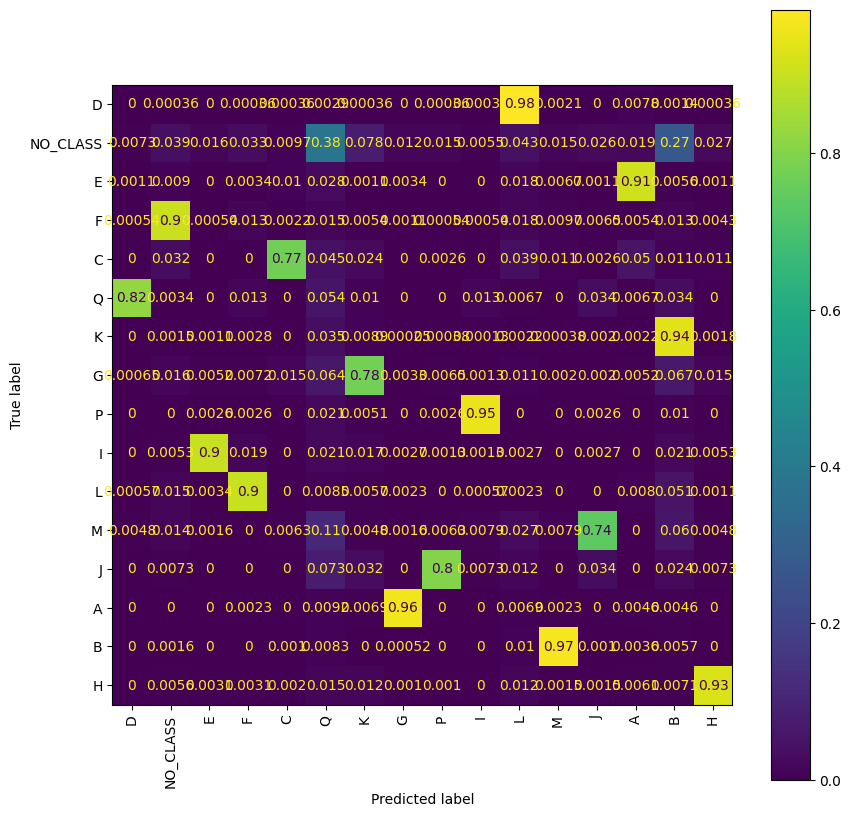

NameError: name 'results_txt' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label_mapping.keys()))
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation="vertical")
plt.show()
plt.savefig(results_path + "/conf_matrix.png")

with open(results_path + "/results_txt.txt", "w") as f:
    f.write(results_txt)

logs = pd.DataFrame(trainer.state.log_history)
logs.head()

plt.figure(figsize=(8,5))

plt.figure(figsize=(8,5))
logs_epoch = logs.dropna(subset="loss")
eval_loss_epoch = logs.dropna(subset="eval_loss")
plt.plot(logs_epoch["epoch"], logs_epoch["loss"], label="Training Loss")
if "eval_loss" in logs:
    plt.plot(eval_loss_epoch["epoch"], eval_loss_epoch["eval_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch")
plt.legend()
plt.savefig(results_path + "/losses.png")